# Evaluación de modelo

Contenido:
- Visualización de predicción (3X3) vs etiqueta
- Matriz de confusión
- Metricas del modelo (Presición, sencibilidad, etc)


## 1. Configuración e importación de módulos del proyecto

In [1]:
# Evaluacion del modelo XYRON Vision

import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, multilabel_confusion_matrix
from torch.utils.data import DataLoader


def buscar_raiz_proyecto(marca='requirements.txt'):
    """Subo por los directorios padre hasta encontrar la marca del proyecto y devuelvo esa ruta."""
    directorio = Path.cwd()
    for _ in range(5):
        if (directorio / marca).exists():
            return directorio
        directorio = directorio.parent
    raise FileNotFoundError('No encontre la raiz del proyecto')


RAIZ_PROYECTO = buscar_raiz_proyecto()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.append(str(RAIZ_PROYECTO))

from src.data.augmentation import get_val_transforms
from src.data.dataset import DatasetSoldadura
from src.models.xyron_model import XyronMobileNetV2
from src.training.checkpoint_utils import cargar_modelo
from src.training.trainer import iou_cajas, obtener_dispositivo


In [2]:
# Parametros de configuracion

RUTA_DATOS_TEST = RAIZ_PROYECTO / 'data_1' / 'test'
RUTA_CHECKPOINT = RAIZ_PROYECTO / 'checkpoints' / 'xyron_mnv2.pt'
IMG_SIZE = 640
NUM_CLASES = 3
NOMBRES_CLASES = ['Bad Weld', 'Good Weld', 'Defect']
UMBRAL_CLASE = 0.5
CANTIDAD_EJEMPLOS = 9
SEMILLA = 42
BATCH_SIZE_TEST = 8

MEDIA_IMAGENET = np.array([0.485, 0.456, 0.406])
DESVIACION_IMAGENET = np.array([0.229, 0.224, 0.225])


## 2. Funciones auxiliares

In [3]:
def desnormalizar_imagen(tensor_imagen):
    """Deshago la normalizacion de ImageNet y devuelvo la imagen como arreglo uint8 en formato HWC."""
    imagen = tensor_imagen.cpu().numpy().transpose(1, 2, 0)
    imagen = imagen * DESVIACION_IMAGENET + MEDIA_IMAGENET
    imagen = np.clip(imagen, 0, 1)
    return (imagen * 255).astype(np.uint8)


def dibujar_caja(imagen, caja, color, grosor=2):
    """Dibujo sobre una copia de la imagen la caja en formato yolo normalizado y devuelvo la copia."""
    alto, ancho = imagen.shape[:2]
    xc, yc, w, h = caja
    x1 = int((xc - w / 2) * ancho)
    y1 = int((yc - h / 2) * alto)
    x2 = int((xc + w / 2) * ancho)
    y2 = int((yc + h / 2) * alto)

    copia = imagen.copy()
    cv2.rectangle(copia, (x1, y1), (x2, y2), color, grosor)
    return copia


def etiquetas_texto(vector, nombres_clases, umbral):
    """Convierto un vector multietiqueta en el texto de las clases activas, o 'Sin clase' si ninguna supera el umbral."""
    activas = [nombre for nombre, valor in zip(nombres_clases, vector) if valor >= umbral]
    return ', '.join(activas) if activas else 'Sin clase'


In [4]:
@torch.no_grad()
def correr_inferencia(modelo, cargador, dispositivo):
    """Recorro el cargador de test y devuelvo las imagenes desnormalizadas junto con clases y cajas reales y predichas."""
    modelo.eval()
    imagenes_lista = []
    clases_reales = []
    clases_predichas = []
    cajas_reales = []
    cajas_predichas = []
    mascaras = []

    for imagenes, vector_clases, cajas, mascara in cargador:
        imagenes = imagenes.to(dispositivo)
        salida_clase, salida_caja = modelo(imagenes)
        probabilidades = torch.sigmoid(salida_clase).cpu()

        for indice in range(imagenes.size(0)):
            imagenes_lista.append(desnormalizar_imagen(imagenes[indice]))

        clases_reales.append(vector_clases)
        clases_predichas.append(probabilidades)
        cajas_reales.append(cajas)
        cajas_predichas.append(salida_caja.cpu())
        mascaras.append(mascara)

    return (
        imagenes_lista,
        torch.cat(clases_reales).numpy(),
        torch.cat(clases_predichas).numpy(),
        torch.cat(cajas_reales).numpy(),
        torch.cat(cajas_predichas).numpy(),
        torch.cat(mascaras).numpy(),
    )


In [5]:
def graficar_cuadricula_predicciones(imagenes, reales, predichas, cajas_reales, cajas_predichas, mascaras, cantidad, semilla):
    """Muestro una cuadricula de imagenes de test con la caja real en verde y la predicha en rojo, junto con las clases de cada una."""
    generador = np.random.default_rng(semilla)
    indices = generador.choice(len(imagenes), size=min(cantidad, len(imagenes)), replace=False)

    lado = int(np.ceil(np.sqrt(len(indices))))
    figura, ejes = plt.subplots(lado, lado, figsize=(4 * lado, 4 * lado))
    ejes = np.atleast_1d(ejes).flatten()

    for eje, indice in zip(ejes, indices):
        imagen = imagenes[indice]
        if mascaras[indice] > 0:
            imagen = dibujar_caja(imagen, cajas_reales[indice], (0, 255, 0))
        imagen = dibujar_caja(imagen, cajas_predichas[indice], (255, 0, 0))

        eje.imshow(imagen)
        eje.set_title(
            f"Real: {etiquetas_texto(reales[indice], NOMBRES_CLASES, UMBRAL_CLASE)}\n"
            f"Prediccion: {etiquetas_texto(predichas[indice], NOMBRES_CLASES, UMBRAL_CLASE)}",
            fontsize=9,
        )
        eje.axis('off')

    for eje in ejes[len(indices):]:
        eje.axis('off')

    figura.suptitle('Verde: caja real | Rojo: caja predicha', fontsize=12)
    figura.tight_layout()
    plt.show()


def graficar_matrices_confusion(reales, predichas, nombres_clases, umbral):
    """Grafico la matriz de confusion binaria de cada clase a partir de las predicciones multietiqueta."""
    predicciones_binarias = (predichas >= umbral).astype(int)
    matrices = multilabel_confusion_matrix(reales.astype(int), predicciones_binarias)

    figura, ejes = plt.subplots(1, len(nombres_clases), figsize=(5 * len(nombres_clases), 4))
    for eje, matriz, nombre in zip(ejes, matrices, nombres_clases):
        eje.imshow(matriz, cmap='Blues')
        eje.set_title(nombre)
        eje.set_xlabel('Prediccion')
        eje.set_ylabel('Real')
        eje.set_xticks([0, 1])
        eje.set_yticks([0, 1])
        eje.set_xticklabels(['Negativo', 'Positivo'])
        eje.set_yticklabels(['Negativo', 'Positivo'])
        for fila in range(2):
            for columna in range(2):
                eje.text(columna, fila, matriz[fila, columna], ha='center', va='center', fontsize=12)

    figura.tight_layout()
    plt.show()


def graficar_metricas_por_clase(reales, predichas, nombres_clases, umbral):
    """Grafico precision, sensibilidad y F1 por clase para compararlas visualmente y no solo como numeros sueltos."""
    predicciones_binarias = (predichas >= umbral).astype(int)
    reporte = classification_report(
        reales.astype(int), predicciones_binarias, target_names=nombres_clases, output_dict=True, zero_division=0
    )

    claves_sklearn = ['precision', 'recall', 'f1-score']
    etiquetas_metricas = ['Precision', 'Sensibilidad', 'F1']
    valores = np.array([[reporte[nombre][clave] for clave in claves_sklearn] for nombre in nombres_clases])

    posiciones = np.arange(len(nombres_clases))
    ancho_barra = 0.25

    figura, eje = plt.subplots(figsize=(8, 5))
    for indice, etiqueta in enumerate(etiquetas_metricas):
        eje.bar(posiciones + indice * ancho_barra, valores[:, indice], ancho_barra, label=etiqueta)

    eje.set_xticks(posiciones + ancho_barra)
    eje.set_xticklabels(nombres_clases)
    eje.set_ylim(0, 1.05)
    eje.set_ylabel('Valor')
    eje.set_title('Metricas por clase')
    eje.legend()
    figura.tight_layout()
    plt.show()

    return reporte


def graficar_distribucion_iou(cajas_reales, cajas_predichas, mascaras):
    """Grafico el histograma de IoU entre la caja predicha y la real para las imagenes que tienen caja valida."""
    indices_validos = mascaras.squeeze(-1) > 0
    iou = iou_cajas(
        torch.from_numpy(cajas_predichas[indices_validos]), torch.from_numpy(cajas_reales[indices_validos])
    ).numpy()

    figura, eje = plt.subplots(figsize=(6, 4))
    eje.hist(iou, bins=15, color='steelblue', edgecolor='black')
    eje.axvline(iou.mean(), color='red', linestyle='--', label=f'Media: {iou.mean():.2f}')
    eje.set_xlabel('IoU')
    eje.set_ylabel('Cantidad de imagenes')
    eje.set_title('Distribucion de IoU en el conjunto de test')
    eje.legend()
    figura.tight_layout()
    plt.show()


## 3. Carga del modelo y del conjunto de test

In [6]:
dispositivo = obtener_dispositivo()

dataset_test = DatasetSoldadura(str(RUTA_DATOS_TEST), NUM_CLASES, get_val_transforms(IMG_SIZE))
cargador_test = DataLoader(dataset_test, batch_size=BATCH_SIZE_TEST, shuffle=False)

modelo = XyronMobileNetV2(NUM_CLASES).to(dispositivo)
epoca, metricas_entrenamiento = cargar_modelo(modelo, None, str(RUTA_CHECKPOINT), dispositivo)

print(f"Dispositivo: {dispositivo}")
print(f"Checkpoint de la epoca {epoca} | metricas de validacion guardadas: {metricas_entrenamiento}")
print(f"Imagenes de test: {len(dataset_test)}")


Dispositivo: cuda
Checkpoint de la epoca 3 | metricas de validacion guardadas: {'perdida_validacion': 0.609542911662195, 'f1_macro': 0.6927358508110046, 'iou_media': 0.22613308662758733}
Imagenes de test: 56


In [7]:
imagenes, clases_reales, clases_predichas, cajas_reales, cajas_predichas, mascaras = correr_inferencia(
    modelo, cargador_test, dispositivo
)


## 4. Visualización de predicciones (3x3) vs etiqueta real

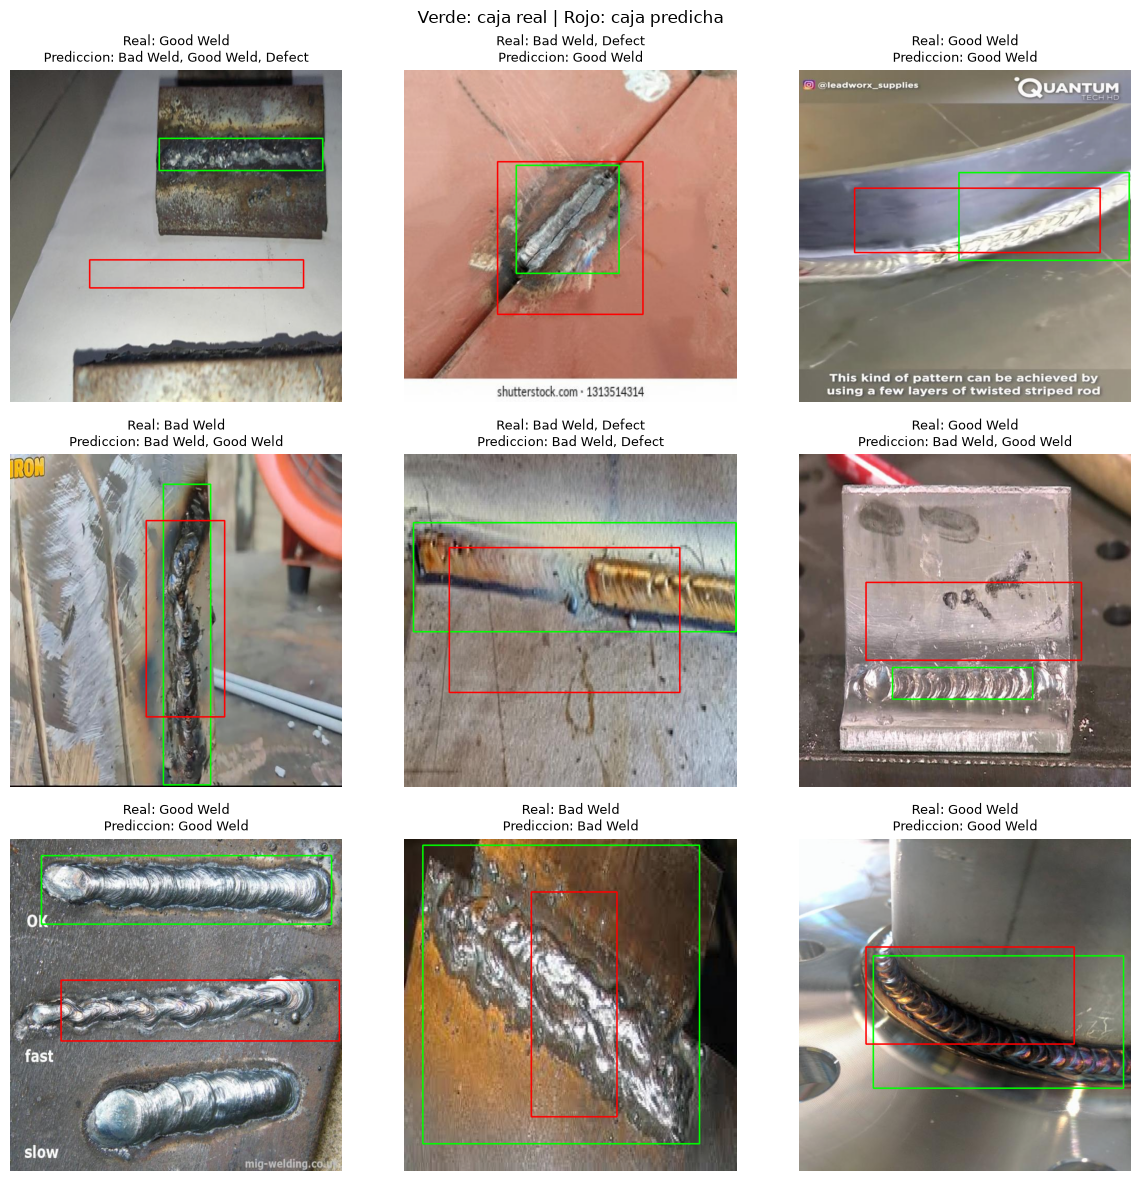

In [8]:
graficar_cuadricula_predicciones(
    imagenes, clases_reales, clases_predichas, cajas_reales, cajas_predichas, mascaras, CANTIDAD_EJEMPLOS, SEMILLA
)


## 5. Matriz de confusión por clase

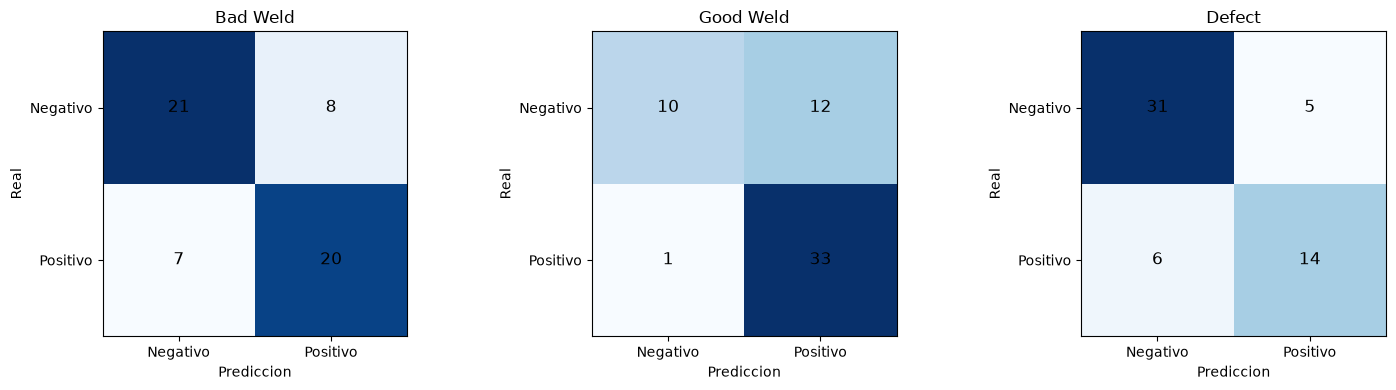

In [9]:
graficar_matrices_confusion(clases_reales, clases_predichas, NOMBRES_CLASES, UMBRAL_CLASE)


## 6. Métricas del modelo (precisión, sensibilidad, F1)

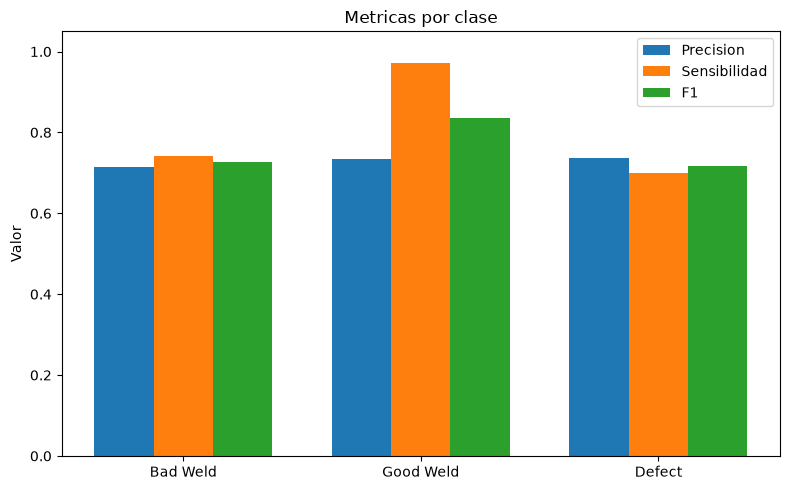

              precision    recall  f1-score   support

    Bad Weld       0.71      0.74      0.73        27
   Good Weld       0.73      0.97      0.84        34
      Defect       0.74      0.70      0.72        20

   micro avg       0.73      0.83      0.77        81
   macro avg       0.73      0.80      0.76        81
weighted avg       0.73      0.83      0.77        81
 samples avg       0.74      0.84      0.76        81



In [10]:
reporte = graficar_metricas_por_clase(clases_reales, clases_predichas, NOMBRES_CLASES, UMBRAL_CLASE)

predicciones_binarias = (clases_predichas >= UMBRAL_CLASE).astype(int)
print(classification_report(
    clases_reales.astype(int), predicciones_binarias, target_names=NOMBRES_CLASES, zero_division=0
))


## 7. Distribución de IoU de la caja predicha

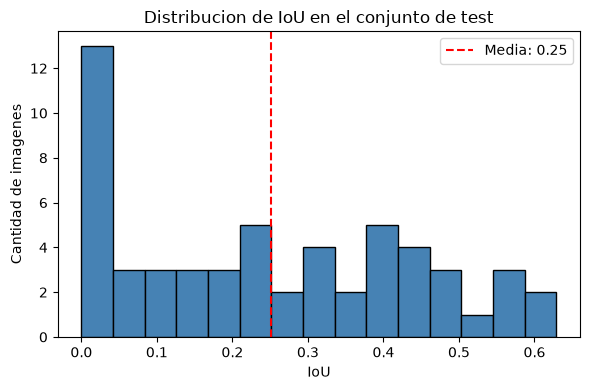

In [11]:
graficar_distribucion_iou(cajas_reales, cajas_predichas, mascaras)
